# 1D Heat Diffusion: From Physics to Numerical Simulation

This notebook develops a numerical model of heat diffusion in a one-dimensional rod.

The main goal is to understand the physical and mathematical foundations of the heat equation before moving toward more advanced Scientific Machine Learning methods such as Physics-Informed Neural Networks (PINNs).

We will gradually cover:

- heat diffusion and temperature gradients
- the 1D heat equation
- initial and boundary conditions
- spatial and temporal discretization
- finite-difference approximations
- the FTCS numerical scheme
- numerical stability
- simulation and visualization of heat diffusion

The long-term goal is to use this numerical model as the physics foundation for a physics-informed digital twin.

## 1. Physical Problem

Consider a one-dimensional rod whose temperature varies with both position and time.

The temperature field is represented as:

$$
T(x,t)
$$

where:

- $x$ represents position along the rod
- $t$ represents time
- $T(x,t)$ represents the temperature at position $x$ and time $t$

If one region of the rod is hotter than another, thermal energy is transferred from the hotter region toward the colder region through conduction.

For example, if the center of the rod is initially much hotter than the rest of the rod, heat will diffuse outward toward both sides.

## 2. Heat Conduction and Fourier's Law

Heat conduction is described by Fourier's law:

$$
q = -k\frac{\partial T}{\partial x}
$$

where:

- $q$ is the heat flux
- $k$ is the thermal conductivity of the material
- $\frac{\partial T}{\partial x}$ is the temperature gradient

The negative sign indicates that heat flows from regions of higher temperature toward regions of lower temperature.

The first spatial derivative therefore describes how temperature changes with position and determines the direction of heat flow.

## 3. The One-Dimensional Heat Equation

Combining Fourier's law with conservation of energy gives the one-dimensional heat equation:

$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial x^2}
$$

where the thermal diffusivity is:

$$
\alpha = \frac{k}{\rho c_p}
$$

Here:

- $k$ is thermal conductivity
- $\rho$ is density
- $c_p$ is specific heat capacity

Thermal diffusivity describes how quickly temperature differences spread through a material.

The term

$$
\frac{\partial T}{\partial t}
$$

describes how temperature changes with time.

The term

$$
\frac{\partial^2 T}{\partial x^2}
$$

describes the curvature of the spatial temperature profile.

A hot local maximum has negative curvature and tends to cool, while a cold local minimum has positive curvature and tends to warm.

## 4. Initial and Boundary Conditions

The heat equation alone is not enough to determine a unique temperature evolution.

We also need:

- an initial temperature distribution
- boundary conditions at the ends of the rod

### Initial condition

For our simplified example:

$$
T^0 = [20,\ 20,\ 100,\ 20,\ 20]
$$

The center of the rod starts at $100^\circ C$, while the remaining points start at $20^\circ C$.

### Boundary conditions

The temperatures at both ends of the rod are kept fixed at:

$$
T(0,t)=20^\circ C
$$

and

$$
T(L,t)=20^\circ C
$$

These are Dirichlet boundary conditions.

Because the endpoints remain fixed at $20^\circ C$, heat can eventually leave the rod through the boundaries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
T = np.array([20.,20.,100.,20.,20.])
print(T)

[ 20.  20. 100.  20.  20.]


## 5. Discretizing Space and Time

The heat equation describes a continuous physical system.

A computer, however, works with a finite number of values. Therefore, space and time are divided into discrete intervals.

The spatial distance between neighboring grid points is:

$$
\Delta x
$$

and the time interval between successive simulation steps is:

$$
\Delta t
$$

The temperature at spatial grid point $i$ and time step $n$ is written as:

$$
T_i^n
$$

where:

- $i$ represents the spatial grid point
- $n$ represents the time step

## 6. Finite-Difference Approximation in Space

The heat equation contains the second spatial derivative:

$$
\frac{\partial^2 T}{\partial x^2}
$$

Using a centered finite-difference approximation:

$$
\frac{\partial^2 T}{\partial x^2}
\approx
\frac{
T_{i+1}^n - 2T_i^n + T_{i-1}^n
}{
\Delta x^2
}
$$

This uses the temperature at the current grid point and its two neighboring points.

The expression

$$
T_{i+1} - 2T_i + T_{i-1}
$$

acts as a discrete measure of the curvature of the temperature profile.

## 7. Finite-Difference Approximation in Time

The time derivative is approximated using a forward difference:

$$
\frac{\partial T}{\partial t}
\approx
\frac{
T_i^{n+1} - T_i^n
}{
\Delta t
}
$$

This measures the change in temperature between the current time step and the next time step.

The forward-time approximation is first-order accurate in time:

$$
O(\Delta t)
$$

## 8. FTCS Numerical Scheme

Substituting the finite-difference approximations into the heat equation gives:

$$
\frac{
T_i^{n+1} - T_i^n
}{
\Delta t
}
=
\alpha
\frac{
T_{i+1}^n - 2T_i^n + T_{i-1}^n
}{
\Delta x^2
}
$$

Rearranging for the future temperature:

$$
T_i^{n+1}
=
T_i^n
+
\frac{\alpha \Delta t}{\Delta x^2}
\left(
T_{i+1}^n - 2T_i^n + T_{i-1}^n
\right)
$$

Define the diffusion number:

$$
r =
\frac{\alpha \Delta t}{\Delta x^2}
$$

Then the update equation becomes:

$$
T_i^{n+1}
=
T_i^n
+
r
\left(
T_{i+1}^n - 2T_i^n + T_{i-1}^n
\right)
$$

This numerical method is called FTCS:

- **Forward in Time**
- **Centered in Space**

In [3]:
r = 0.1

## 9. Stability Condition

For the explicit one-dimensional FTCS heat solver, the diffusion number must satisfy:

$$
r \leq 0.5
$$

or equivalently:

$$
\frac{\alpha \Delta t}{\Delta x^2}
\leq 0.5
$$

If $r$ becomes too large, the numerical solution may become unstable and produce oscillating or physically unrealistic temperatures.

Therefore, the choices of $\Delta x$ and $\Delta t$ are important for numerical stability.

## 10. Updating the Temperature Field

Every new temperature value must be calculated using temperatures from the same previous time step.

Therefore, the current temperature array should not be overwritten while the new time step is being calculated.

We create a separate array:

$$
T^n \rightarrow T^{n+1}
$$

After all interior points have been updated, the new temperature field becomes the current temperature field.

In [4]:
T_new = T.copy()

In [5]:
i = 2

T_new[i] = T[i] + r * (
    T[i+1] - 2*T[i] + T[i-1]
)

print(T_new)

[20. 20. 84. 20. 20.]


## 11. One Complete FTCS Time Step

The boundary points remain fixed at $20^\circ C$.

Therefore, only the interior grid points are updated.

For the five-point rod, the updated indices are:

$$
i = 1,\ 2,\ 3
$$

while indices $0$ and $4$ remain fixed.

In [6]:
T = np.array([20., 20., 100., 20., 20.])
T_new = T.copy()

for i in range(1, len(T) - 1):
    T_new[i] = T[i] + r * (
        T[i+1] - 2*T[i] + T[i-1]
    )

print(T_new)

[20. 28. 84. 28. 20.]


### Observation

After one time step, the temperature at the center decreases, while the temperatures at the neighboring points increase.

This shows that heat is diffusing from the hotter central region toward the colder surrounding regions.

## 12. Simulating Multiple Time Steps

To observe the full diffusion process, the FTCS update is repeated over several time steps.

The temperature field evolves as:

$$
T^0
\rightarrow
T^1
\rightarrow
T^2
\rightarrow
T^3
\rightarrow
\cdots
$$

Each temperature profile is stored so that the evolution of the system can later be visualized and analyzed.

In [7]:
T = np.array([20., 20., 100., 20., 20.])

r = 0.1
n_steps = 5

history = [T.copy()]

for n in range(n_steps):
    T_new = T.copy()

    for i in range(1, len(T) - 1):
        T_new[i] = T[i] + r * (
            T[i+1] - 2*T[i] + T[i-1]
        )

    T = T_new
    history.append(T.copy())

history

[array([ 20.,  20., 100.,  20.,  20.]),
 array([20., 28., 84., 28., 20.]),
 array([20. , 32.8, 72.8, 32.8, 20. ]),
 array([20.  , 35.52, 64.8 , 35.52, 20.  ]),
 array([20.   , 36.896, 58.944, 36.896, 20.   ]),
 array([20.    , 37.4112, 54.5344, 37.4112, 20.    ])]

## 13. Organizing the Simulation Results

The temperature profile at every time step has been stored in `history`.

To make the results easier to analyze and visualize, the stored profiles are converted into a two-dimensional NumPy array.

Each row represents one time step, while each column represents one spatial grid point.

Therefore, the temperature field can be viewed as:

$$
T(n,i)
$$

where:

- $n$ represents the time step
- $i$ represents the spatial grid point

In [8]:
history = np.array(history)

print(history)
print("Shape:", history.shape)

[[ 20.      20.     100.      20.      20.    ]
 [ 20.      28.      84.      28.      20.    ]
 [ 20.      32.8     72.8     32.8     20.    ]
 [ 20.      35.52    64.8     35.52    20.    ]
 [ 20.      36.896   58.944   36.896   20.    ]
 [ 20.      37.4112  54.5344  37.4112  20.    ]]
Shape: (6, 5)


## 14. Spatial Grid

Until now, the five temperature values represented abstract grid points.

We now assign physical positions to these points.

Assume the rod has a length:

$$
L = 1 \text{ m}
$$

The five grid points are distributed evenly between:

$$
x=0
$$

and

$$
x=L
$$

The spacing between neighboring points is:

$$
\Delta x = \frac{L}{N_x-1}
$$

where $N_x$ is the number of spatial grid points.

In [9]:
L = 1.0
nx = len(T)

x = np.linspace(0, L, nx)

dx = x[1] - x[0]

print("Spatial positions:", x)
print("dx =", dx)

Spatial positions: [0.   0.25 0.5  0.75 1.  ]
dx = 0.25


## 15. Visualizing the Temperature Evolution

The temperature profiles can now be plotted as a function of position.

Each curve represents the temperature distribution along the rod at a different time step.

As diffusion occurs, the initially sharp temperature peak at the center should gradually become lower and broader.

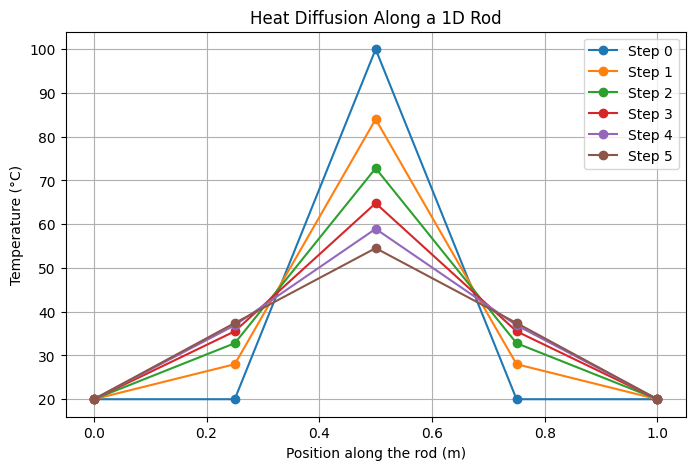

In [10]:
plt.figure(figsize=(8, 5))

for n in range(len(history)):
    plt.plot(
        x,
        history[n],
        marker="o",
        label=f"Step {n}"
    )

plt.xlabel("Position along the rod (m)")
plt.ylabel("Temperature (°C)")
plt.title("Heat Diffusion Along a 1D Rod")
plt.legend()
plt.grid()

plt.show()

### Observation

The initial temperature distribution contains a sharp peak of $100^\circ C$ at the center of the rod.

As the simulation progresses, the temperature at the center decreases while the temperatures at the neighboring points increase.

The temperature profile gradually becomes smoother and flatter, which represents the diffusion of thermal energy from the hotter central region toward the cooler regions of the rod.

The temperatures at both endpoints remain fixed at $20^\circ C$ because Dirichlet boundary conditions are applied.

## 16. Introducing Physical Simulation Parameters

Until now, the diffusion number was chosen directly as:

$$
r = 0.1
$$

However, the diffusion number is determined by the physical and numerical parameters:

$$
r = \frac{\alpha \Delta t}{\Delta x^2}
$$

For the current simulation:

$$
L = 1.0 \text{ m}
$$

$$
\Delta x = 0.25 \text{ m}
$$

$$
\alpha = 0.01 \text{ m}^2/\text{s}
$$

To maintain a diffusion number of $r=0.1$, the required time step is:

$$
\Delta t
=
\frac{r\Delta x^2}{\alpha}
$$

which gives:

$$
\Delta t = 0.625 \text{ s}
$$

Therefore, each numerical update represents $0.625$ seconds of physical time.

In [11]:
alpha = 0.01

dt = r * dx**2 / alpha

print("Thermal diffusivity =", alpha, "m²/s")
print("Spatial step dx =", dx, "m")
print("Time step dt =", dt, "s")

r_check = alpha * dt / dx**2

print("Diffusion number r =", r_check)

Thermal diffusivity = 0.01 m²/s
Spatial step dx = 0.25 m
Time step dt = 0.625 s
Diffusion number r = 0.1
